# 04_phase2_clustering_annotation_clean.ipynb — CLEANED
Phase 2 — Clustering and Cell Type Annotation

**Changes this pass:**
- Removed duplicate resolution-comparison cell (kept the 5-panel version showing all tested resolutions)
- Added Cell 14b/14c: sub-clustering and marker validation for cluster 5 ("Monocytes/DC"), matching the same rigour already applied to cluster 3 ("Macrophages") in Cell 13/14 — this was previously the only annotated population never independently validated, despite showing the strongest raw CD68/LYZ/TYROBP signal of any cluster in Cell 6
- Clarified file-naming/memory-management comments (Cell 10, Cell 15)
- Renumbered cells sequentially

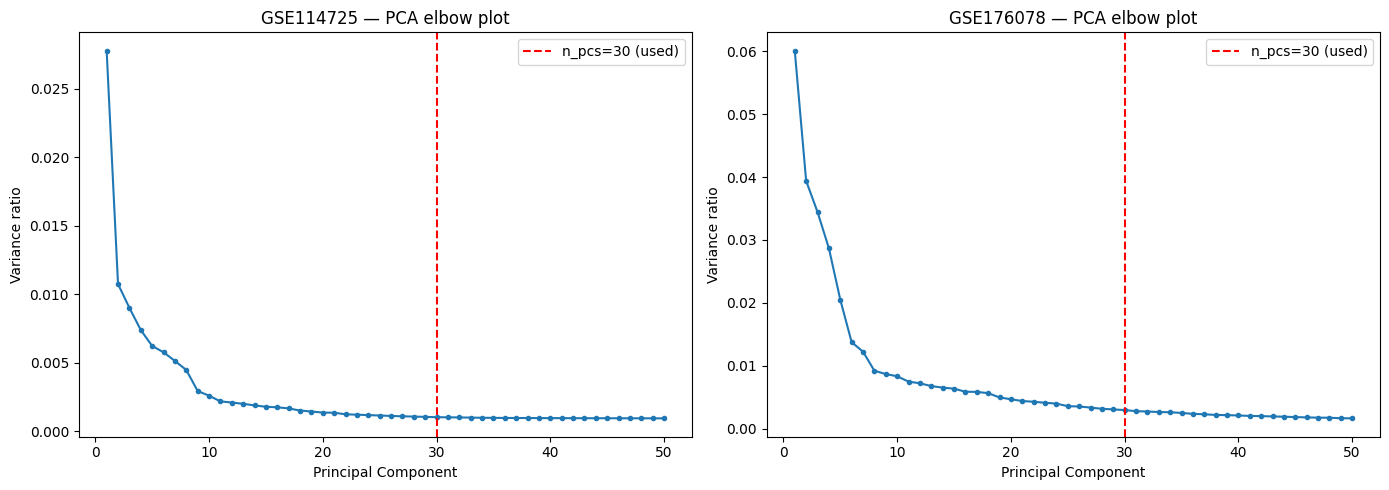

Saved PCA_elbow_plots.png


In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, name, adata in zip(axes, ["GSE114725", "GSE176078"], [adata1, adata2]):
    var_ratio = adata.uns["pca"]["variance_ratio"][:50]
    ax.plot(range(1, 51), var_ratio, marker='o', markersize=3)
    ax.axvline(x=30, color='red', linestyle='--', label='n_pcs=30 (used)')
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Variance ratio")
    ax.set_title(f"{name} — PCA elbow plot")
    ax.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "PCA_elbow_plots.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved PCA_elbow_plots.png")

In [1]:
# ----------------------------
# FIX (reproducibility): force single-threaded execution BEFORE scanpy
# import. Approximate nearest-neighbour search (pynndescent, used inside
# sc.pp.neighbors) runs multi-threaded by default. Multi-threaded
# floating-point computation isn't guaranteed bit-identical run to run —
# thread completion order varies, and float addition isn't strictly
# order-independent. This was invisible for most clusters but was enough
# to change GSE114725's res 0.6 cluster count from 6 to 13 between two
# otherwise-identical seeded runs. Must be set before scanpy is imported
# anywhere in this kernel session — a genuine restart is required for
# this to take effect if scanpy was already imported.
# ----------------------------
import os
os.environ["NUMBA_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"


In [2]:
# ============================================================
# 04_phase2_clustering_annotation_clean.ipynb
# Phase 2 — Clustering and Cell Type Annotation
# GSE114725 (Azizi et al. 2018) and GSE176078 (Wu et al. 2021)
# ============================================================

# ----------------------------
# Cell 1 — Imports and paths
# ----------------------------
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
from pathlib import Path
from scipy.sparse import issparse

sc.settings.verbosity = 1

PROJECT_DIR = Path(r"C:\Users\annam\Dissertation 2026")
PROCESSED_DIR = PROJECT_DIR / "Data" / "Processed"
FIGURE_DIR = PROJECT_DIR / "figures" / "phase2_clustering_v2"
RESULTS_DIR = PROJECT_DIR / "results" / "phase2_clustering_v2"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Ready")

Ready


In [3]:
# ----------------------------
# Cell 2 — Load Phase 1 v2 objects
# ----------------------------
adata1 = sc.read_h5ad(PROCESSED_DIR / "GSE114725_phase1_v2.h5ad")
adata2 = sc.read_h5ad(PROCESSED_DIR / "GSE176078_phase1_v2.h5ad")

print("GSE114725:", adata1.n_obs, "cells x", adata1.n_vars, "genes")
print("GSE176078:", adata2.n_obs, "cells x", adata2.n_vars, "genes")
print("\nGSE114725 obs:", list(adata1.obs.columns))
print("GSE176078 obs:", list(adata2.obs.columns))

GSE114725: 44662 cells x 2000 genes
GSE176078: 91425 cells x 2000 genes

GSE114725 obs: ['patient', 'tissue', 'replicate', 'cluster', 'n_genes_by_counts', 'total_counts', 'doublet_score', 'predicted_doublet']
GSE176078 obs: ['Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'dataset', 'n_genes_by_counts', 'total_counts', 'doublet_score', 'predicted_doublet']


In [4]:
# ----------------------------
# Cell 3 — Leiden clustering at multiple resolutions
# Neighbours built on X_pca_harmony (Harmony-corrected PCA)
# ----------------------------
sc.pp.neighbors(adata1, use_rep="X_pca_harmony", n_neighbors=15, n_pcs=30, random_state=0)
sc.pp.neighbors(adata2, use_rep="X_pca_harmony", n_neighbors=15, n_pcs=30, random_state=0)

for res in [0.2, 0.4, 0.6, 0.8, 1.0]:
    sc.tl.leiden(adata1, resolution=res, key_added=f"leiden_{res}",
                 flavor="igraph", n_iterations=2, directed=False, random_state=0)
    sc.tl.leiden(adata2, resolution=res, key_added=f"leiden_{res}",
                 flavor="igraph", n_iterations=2, directed=False, random_state=0)
    print(f"Resolution {res}: GSE114725={adata1.obs[f'leiden_{res}'].nunique()} "
          f"clusters, GSE176078={adata2.obs[f'leiden_{res}'].nunique()} clusters")

C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Resolution 0.2: GSE114725=9 clusters, GSE176078=16 clusters
Resolution 0.4: GSE114725=11 clusters, GSE176078=22 clusters
Resolution 0.6: GSE114725=13 clusters, GSE176078=28 clusters
Resolution 0.8: GSE114725=14 clusters, GSE176078=32 clusters
Resolution 1.0: GSE114725=19 clusters, GSE176078=31 clusters


In [6]:
# ----------------------------
# NEW — Resolution selection for GSE114725, re-done against the
# now-stable (seeded, single-threaded) embedding.
# Motivation: res 0.6 gave 13 clusters this time (vs 6 originally,
# before seeding). The UMAP shape is the same across resolutions —
# same broad regions — just subdivided differently, consistent with
# the notebook's own earlier note that higher resolutions here produce
# "ambiguous clusters not supported by canonical markers." This checks
# canonical markers at 0.2/0.4/0.6 to pick a resolution that gives
# distinct populations without redundant splits, rather than assuming
# 0.6 is still the right choice for this embedding.
# ----------------------------
canonical_markers_screen = {
    "T cells": ["CD3D", "CD3E", "TCF7"],
    "NK/Cytotoxic": ["NKG7", "GNLY", "PRF1"],
    "Activated T": ["FOS", "JUN", "CD69"],
    "Macrophages": ["CD68", "LYZ", "TYROBP", "C1QA"],
    "B cells": ["CD79A", "MS4A1", "CD19"],
    "Monocytes/DC": ["S100A8", "S100A9", "CD14", "FCN1"],
    "Mast cells": ["CPA3", "KIT", "TPSB2"],
}

adata1_raw_screen = adata1.raw.to_adata()

for res in [0.2, 0.4, 0.6]:
    key = f"leiden_{res}"
    n_clusters = adata1.obs[key].nunique()
    print(f"\n{'='*60}")
    print(f"RESOLUTION {res} — {n_clusters} clusters")
    print(f"{'='*60}")

    adata1_raw_screen.obs[key] = adata1.obs[key].values

    for pop, genes in canonical_markers_screen.items():
        print(f"\n  {pop}:")
        for gene in genes:
            if gene not in adata1_raw_screen.var_names:
                continue
            vals = []
            for cl in sorted(adata1.obs[key].unique(), key=int):
                mask = (adata1_raw_screen.obs[key] == cl).values
                X = adata1_raw_screen[mask, gene].X
                if issparse(X): X = X.toarray()
                vals.append(f"C{cl}={X.mean():.2f}")
            print(f"    {gene}: {', '.join(vals)}")

    # cluster sizes, to spot tiny/redundant splits at a glance
    print(f"\n  Cluster sizes: {dict(adata1.obs[key].value_counts().sort_index())}")

del adata1_raw_screen
gc.collect()

print("\n\n>>> ACTION: look for the LOWEST resolution where every biologically")
print(">>> distinct population (T/NK/Activated T/Macrophage/B/Monocyte/Mast)")
print(">>> has its own cluster with a clean marker signal, and no cluster")
print(">>> looks like a near-duplicate of another (same markers, split only")
print(">>> by a small numeric difference). That resolution — not necessarily")
print(">>> 0.6 — is your new working resolution going forward.")


RESOLUTION 0.2 — 9 clusters

  T cells:
    CD3D: C0=0.88, C1=0.94, C2=0.71, C3=0.55, C4=0.04, C5=0.11, C6=0.09, C7=0.13, C8=0.12
    CD3E: C0=0.81, C1=0.83, C2=0.66, C3=0.52, C4=0.03, C5=0.09, C6=0.14, C7=0.11, C8=0.07
    TCF7: C0=1.38, C1=0.48, C2=0.50, C3=0.22, C4=0.23, C5=0.09, C6=0.08, C7=0.10, C8=0.14

  NK/Cytotoxic:
    NKG7: C0=0.10, C1=0.95, C2=0.81, C3=3.22, C4=0.04, C5=0.11, C6=0.17, C7=0.15, C8=0.15
    GNLY: C0=0.11, C1=0.79, C2=1.13, C3=3.78, C4=0.06, C5=0.15, C6=0.15, C7=0.17, C8=0.16
    PRF1: C0=0.14, C1=0.82, C2=1.06, C3=2.99, C4=0.04, C5=0.12, C6=0.15, C7=0.13, C8=0.14

  Activated T:
    FOS: C0=0.89, C1=1.51, C2=2.18, C3=0.47, C4=0.71, C5=2.66, C6=1.87, C7=3.07, C8=3.55
    JUN: C0=0.61, C1=1.29, C2=1.68, C3=0.34, C4=0.89, C5=1.38, C6=0.65, C7=0.58, C8=3.03
    CD69: C0=0.85, C1=1.59, C2=1.44, C3=0.60, C4=0.89, C5=0.41, C6=0.53, C7=0.24, C8=2.87

  Macrophages:
    CD68: C0=0.01, C1=0.04, C2=0.06, C3=0.02, C4=0.07, C5=2.05, C6=1.30, C7=0.20, C8=0.54
    LYZ: C0=

In [5]:
# ----------------------------
# Cell 4 — Resolution comparison UMAPs
# ----------------------------
fig, axes = plt.subplots(1, 5, figsize=(30, 5))
for i, res in enumerate(["leiden_0.2", "leiden_0.4", "leiden_0.6", "leiden_0.8", "leiden_1.0"]):
    sc.pl.umap(adata1, color=res, title=f"GSE114725 {res}",
               legend_loc="on data", legend_fontsize=8, ax=axes[i], show=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE114725_resolution_comparison.png", dpi=300, bbox_inches="tight")
plt.close()

fig, axes = plt.subplots(1, 5, figsize=(30, 5))
for i, res in enumerate(["leiden_0.2", "leiden_0.4", "leiden_0.6", "leiden_0.8", "leiden_1.0"]):
    sc.pl.umap(adata2, color=res, title=f"GSE176078 {res}",
               legend_loc="on data", legend_fontsize=8, ax=axes[i], show=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE176078_resolution_comparison.png", dpi=300, bbox_inches="tight")
plt.close()

print("Saved — open figures to inspect")

Saved — open figures to inspect


In [7]:
# ----------------------------
# Cell 5 — Marker genes per cluster
# GSE114725: SWITCHED to leiden_0.2 (see Cell 4/7 for why — res 0.6
# produced mixed-identity clusters once the embedding was seeded).
# GSE176078: unchanged, still leiden_0.6.
# Wilcoxon rank-sum test — appropriate for identifying cluster markers
# Note: V(D)J genes removed in Phase 1 so no contamination of marker lists
# ----------------------------
sc.tl.rank_genes_groups(adata1, groupby="leiden_0.2", method="wilcoxon",
                        key_added="rank_genes_leiden_0.2")
sc.tl.rank_genes_groups(adata2, groupby="leiden_0.6", method="wilcoxon",
                        key_added="rank_genes_leiden_0.6")

markers1 = sc.get.rank_genes_groups_df(adata1, group=None, key="rank_genes_leiden_0.2")
markers2 = sc.get.rank_genes_groups_df(adata2, group=None, key="rank_genes_leiden_0.6")

markers1.to_csv(RESULTS_DIR / "GSE114725_markers_v2.csv", index=False)
markers2.to_csv(RESULTS_DIR / "GSE176078_markers_v2.csv", index=False)
markers1.groupby("group").head(10).to_csv(
    RESULTS_DIR / "GSE114725_top10_markers_v2.csv", index=False)
markers2.groupby("group").head(10).to_csv(
    RESULTS_DIR / "GSE176078_top10_markers_v2.csv", index=False)

print("=== GSE114725 Top 5 markers per cluster (res 0.2) ===")
for cl in sorted(markers1["group"].unique(), key=lambda x: int(x)):
    genes = markers1[markers1["group"] == cl].head(5)["names"].tolist()
    print(f"Cluster {cl}: {', '.join(genes)}")

print("\n=== GSE176078 Top 5 markers per cluster (res 0.6) ===")
for cl in sorted(markers2["group"].unique(), key=lambda x: int(x)):
    genes = markers2[markers2["group"] == cl].head(5)["names"].tolist()
    print(f"Cluster {cl}: {', '.join(genes)}")

C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:463: PerformanceWarning: DataFrame is high

=== GSE114725 Top 5 markers per cluster (res 0.2) ===
Cluster 0: TPT1, RPS12, RPL13, RPL30, RPS29
Cluster 1: CCL5, CCL4, CXCR4, CD8A, BTG1
Cluster 2: COL1A1, MGP, DCN, IGFBP7, HBB
Cluster 3: GNLY, NKG7, PRF1, B2M, HLA-B
Cluster 4: CD74, CD79A, HLA-DRA, CD37, HLA-DPB1
Cluster 5: CST3, HLA-DRA, FTL, PSAP, CD74
Cluster 6: JCHAIN, MPEG1, IRF8, IRF7, GZMB
Cluster 7: NEAT1, FTH1, IFITM2, S100A9, FCGR3B
Cluster 8: CPA3, TPSB2, MS4A2, TPSAB1, KIT

=== GSE176078 Top 5 markers per cluster (res 0.6) ===
Cluster 0: RAMP2, SPARCL1, GNG11, PECAM1, PLVAP
Cluster 1: COL1A2, DCN, COL1A1, CTSK, C1S
Cluster 2: MYL9, IGFBP7, CALD1, TPM2, TAGLN
Cluster 3: KRT14, KRT17, KRT5, TAGLN, MT1X
Cluster 4: MS4A1, HLA-DRA, CD37, CD74, CD79A
Cluster 5: B2M, IL32, CD2, CD3D, CD3E
Cluster 6: IL7R, RPS27, RPL30, RPS25, RPS12
Cluster 7: HMGB2, STMN1, HMGN2, TUBB, HMGB1
Cluster 8: SSR4, MZB1, SEC11C, DERL3, FKBP11
Cluster 9: CCL5, NKG7, CD3E, CD8A, CST7
Cluster 10: NKG7, GNLY, KLRD1, CTSW, CCL5
Cluster 11: STMN1, UBE2C, B

In [8]:
# NOTE: added C1QA/C1QB/MRC1 (macrophage-specific) and FCN1 (monocyte-specific)
# to the original panel for extra resolving power on the cluster 3 vs 5 question.
# ----------------------------
# Cell 6 — Canonical marker validation
# Confirms cluster annotations using known lineage markers
# All values from adata.raw (full gene, log-normalised, unscaled)
# GSE114725: SWITCHED to leiden_0.2, matching Cell 5/7.
# ----------------------------
adata1_raw = adata1.raw.to_adata()
adata1_raw.obs["leiden_0.2"] = adata1.obs["leiden_0.2"].values

canonical_markers = {
    "T cells (CD3D, CD3E, TCF7)": ["CD3D", "CD3E", "TCF7", "IL7R", "CCR7"],
    "NK/Cytotoxic (NKG7, GNLY, PRF1)": ["NKG7", "GNLY", "PRF1", "KLRD1", "GZMB"],
    "Activated T (FOS, JUN, CD69)": ["CD69", "FOS", "JUN", "NFKBIA", "DUSP1"],
    "Macrophages (CD68, LYZ, TYROBP, C1QA/B/C, MRC1)": ["CD68", "LYZ", "TYROBP", "CD163", "C1QA", "C1QB", "MRC1"],
    "B cells (CD79A, MS4A1, CD19)": ["CD79A", "MS4A1", "CD19"],
    "Monocytes/DC (S100A8, CD14, FCN1)": ["S100A8", "S100A9", "CD14", "FCGR3A", "VCAN", "FCN1"],
    "Mast cells (CPA3, KIT, TPSB2)": ["CPA3", "KIT", "TPSB2"],
}

print("=== Canonical marker expression per cluster (res 0.2) ===\n")
for pop, genes in canonical_markers.items():
    print(f"{pop}:")
    for gene in genes:
        if gene in adata1_raw.var_names:
            vals = []
            for cl in sorted(adata1.obs["leiden_0.2"].unique(), key=int):
                mask = (adata1_raw.obs["leiden_0.2"] == cl).values
                X = adata1_raw[mask, gene].X
                if issparse(X): X = X.toarray()
                vals.append(f"C{cl}={X.mean():.2f}")
            print(f"  {gene}: {', '.join(vals)}")
    print()

del adata1_raw
gc.collect()

=== Canonical marker expression per cluster (res 0.2) ===

T cells (CD3D, CD3E, TCF7):
  CD3D: C0=0.88, C1=0.94, C2=0.71, C3=0.55, C4=0.04, C5=0.11, C6=0.09, C7=0.13, C8=0.12
  CD3E: C0=0.81, C1=0.83, C2=0.66, C3=0.52, C4=0.03, C5=0.09, C6=0.14, C7=0.11, C8=0.07
  TCF7: C0=1.38, C1=0.48, C2=0.50, C3=0.22, C4=0.23, C5=0.09, C6=0.08, C7=0.10, C8=0.14
  IL7R: C0=1.81, C1=1.39, C2=1.88, C3=0.29, C4=0.14, C5=0.23, C6=0.29, C7=0.22, C8=0.34
  CCR7: C0=0.66, C1=0.10, C2=0.28, C3=0.03, C4=0.43, C5=0.06, C6=0.16, C7=0.04, C8=0.06

NK/Cytotoxic (NKG7, GNLY, PRF1):
  NKG7: C0=0.10, C1=0.95, C2=0.81, C3=3.22, C4=0.04, C5=0.11, C6=0.17, C7=0.15, C8=0.15
  GNLY: C0=0.11, C1=0.79, C2=1.13, C3=3.78, C4=0.06, C5=0.15, C6=0.15, C7=0.17, C8=0.16
  PRF1: C0=0.14, C1=0.82, C2=1.06, C3=2.99, C4=0.04, C5=0.12, C6=0.15, C7=0.13, C8=0.14
  KLRD1: C0=0.05, C1=0.99, C2=0.87, C3=1.82, C4=0.02, C5=0.09, C6=0.08, C7=0.18, C8=0.17
  GZMB: C0=0.03, C1=0.25, C2=0.46, C3=1.77, C4=0.03, C5=0.09, C6=2.99, C7=0.07, C8=0.1

3082

In [10]:
# ----------------------------
# NEW — Full canonical marker validation for GSE176078, all 28 clusters.
# Matches the same rigour Cell 6 already applies to GSE114725. Previously
# most GSE176078 labels were derived from top-5 DE genes + pattern-matching
# against the original run, with only 3 clusters (12/20/21) getting an
# actual marker-panel check. This closes that gap.
# ----------------------------
adata2_raw = adata2.raw.to_adata()
adata2_raw.obs["leiden_0.6"] = adata2.obs["leiden_0.6"].values

canonical_markers_2 = {
    "Endothelial": ["PECAM1", "VWF", "PLVAP", "RAMP2", "CLDN5"],
    "CAFs/Fibroblasts": ["COL1A1", "COL1A2", "DCN", "PDGFRB"],
    "PVL": ["MYL9", "TAGLN", "CALD1", "ACTA2"],
    "Basal epithelial": ["KRT14", "KRT5", "KRT17"],
    "Luminal epithelial": ["ESR1", "FOXA1", "GATA3", "KRT18", "KRT8"],
    "B cells": ["MS4A1", "CD79A", "CD19"],
    "Plasma cells": ["MZB1", "SSR4", "DERL3", "XBP1"],
    "T cells (general)": ["CD3D", "CD3E", "CD2", "IL32"],
    "CD8 T cells": ["CD8A", "CCL5", "NKG7"],
    "NK cells": ["NKG7", "GNLY", "KLRD1"],
    "Macrophages": ["CD68", "LYZ", "C1QA", "AIF1", "TYROBP"],
    "pDC": ["JCHAIN", "IRF7", "IRF8", "GZMB"],
    "Cycling": ["STMN1", "HMGB2", "UBE2C", "BIRC5"],
    "Epithelial (general)": ["EPCAM", "KRT19", "CDH1"],
    "EMT/ambiguous": ["VIM", "SERPINE1", "ZEB1"],
}

print("=== GSE176078 canonical marker expression per cluster (res 0.6) ===\n")
for pop, genes in canonical_markers_2.items():
    print(f"{pop}:")
    for gene in genes:
        if gene in adata2_raw.var_names:
            vals = []
            for cl in sorted(adata2.obs["leiden_0.6"].unique(), key=int):
                mask = (adata2_raw.obs["leiden_0.6"] == cl).values
                X = adata2_raw[mask, gene].X
                if issparse(X): X = X.toarray()
                vals.append(f"C{cl}={X.mean():.2f}")
            print(f"  {gene}: {', '.join(vals)}")
    print()

del adata2_raw
gc.collect()

=== GSE176078 canonical marker expression per cluster (res 0.6) ===

Endothelial:
  PECAM1: C0=2.01, C1=0.03, C2=0.02, C3=0.04, C4=0.05, C5=0.01, C6=0.02, C7=0.13, C8=0.73, C9=0.09, C10=0.09, C11=0.01, C12=0.01, C13=0.01, C14=0.00, C15=0.01, C16=0.01, C17=0.00, C18=0.02, C19=0.40, C20=0.22, C21=0.11, C22=0.31, C23=0.01, C24=0.00, C25=0.00, C26=0.02, C27=0.01
  VWF: C0=1.96, C1=0.02, C2=0.02, C3=0.03, C4=0.01, C5=0.01, C6=0.00, C7=0.00, C8=0.01, C9=0.01, C10=0.01, C11=0.01, C12=0.02, C13=0.01, C14=0.00, C15=0.02, C16=0.00, C17=0.00, C18=0.02, C19=0.01, C20=0.00, C21=0.00, C22=0.01, C23=0.00, C24=0.00, C25=0.00, C26=0.03, C27=0.01
  PLVAP: C0=2.44, C1=0.07, C2=0.08, C3=0.16, C4=0.03, C5=0.01, C6=0.01, C7=0.01, C8=0.02, C9=0.02, C10=0.02, C11=0.01, C12=0.02, C13=0.02, C14=0.04, C15=0.03, C16=0.00, C17=0.00, C18=0.02, C19=0.03, C20=0.00, C21=0.00, C22=0.44, C23=0.00, C24=0.01, C25=0.00, C26=0.03, C27=0.00
  RAMP2: C0=2.41, C1=0.14, C2=0.05, C3=0.04, C4=0.01, C5=0.00, C6=0.01, C7=0.00, C8=0

9318

In [11]:
# Closes the gap for C1, C2, C6 — never covered by the original canonical
# panel. Adds fibroblast and pDC markers specifically, plus CD8A/IL7R to
# properly discriminate C1.
adata1_raw2 = adata1.raw.to_adata()
adata1_raw2.obs["leiden_0.2"] = adata1.obs["leiden_0.2"].values

extra_markers = {
    "Fibroblast/stromal": ["COL1A1", "COL1A2", "DCN", "PDGFRB"],
    "pDC": ["JCHAIN", "IRF7", "IRF8"],
    "CD8/effector T discrimination": ["CD8A", "CD8B", "IL7R", "CCR7"],
}

for pop, genes in extra_markers.items():
    print(f"{pop}:")
    for gene in genes:
        if gene in adata1_raw2.var_names:
            vals = []
            for cl in sorted(adata1.obs["leiden_0.2"].unique(), key=int):
                mask = (adata1_raw2.obs["leiden_0.2"] == cl).values
                X = adata1_raw2[mask, gene].X
                if issparse(X): X = X.toarray()
                vals.append(f"C{cl}={X.mean():.2f}")
            print(f"  {gene}: {', '.join(vals)}")
    print()

del adata1_raw2
gc.collect()

Fibroblast/stromal:
  COL1A1: C0=0.02, C1=0.07, C2=3.05, C3=0.04, C4=0.02, C5=0.24, C6=0.22, C7=0.05, C8=0.46
  COL1A2: C0=0.01, C1=0.03, C2=1.25, C3=0.01, C4=0.01, C5=0.10, C6=0.06, C7=0.03, C8=0.23
  DCN: C0=0.02, C1=0.06, C2=2.28, C3=0.03, C4=0.01, C5=0.12, C6=0.05, C7=0.07, C8=0.37
  PDGFRB: C0=0.00, C1=0.00, C2=0.24, C3=0.13, C4=0.00, C5=0.02, C6=0.01, C7=0.01, C8=0.04

pDC:
  JCHAIN: C0=0.03, C1=0.05, C2=0.40, C3=0.03, C4=0.37, C5=0.13, C6=2.90, C7=0.24, C8=0.38
  IRF7: C0=0.06, C1=0.11, C2=0.10, C3=0.10, C4=0.13, C5=0.29, C6=2.42, C7=0.18, C8=0.13
  IRF8: C0=0.01, C1=0.03, C2=0.06, C3=0.07, C4=0.82, C5=0.39, C6=2.63, C7=0.06, C8=0.06

CD8/effector T discrimination:
  CD8A: C0=0.18, C1=1.43, C2=0.93, C3=0.85, C4=0.03, C5=0.11, C6=0.08, C7=0.12, C8=0.10
  CD8B: C0=0.15, C1=0.79, C2=0.36, C3=0.33, C4=0.01, C5=0.06, C6=0.04, C7=0.05, C8=0.02
  IL7R: C0=1.81, C1=1.39, C2=1.88, C3=0.29, C4=0.14, C5=0.23, C6=0.29, C7=0.22, C8=0.34
  CCR7: C0=0.66, C1=0.10, C2=0.28, C3=0.03, C4=0.43, C5

2576

In [13]:
adata2_raw3 = adata2.raw.to_adata()
adata2_raw3.obs["leiden_0.6"] = adata2.obs["leiden_0.6"].values
for gene in ["IL7R", "CCR7", "SELL", "CD8A"]:
    if gene in adata2_raw3.var_names:
        vals = []
        for cl in ["5", "6"]:
            mask = (adata2_raw3.obs["leiden_0.6"] == cl).values
            X = adata2_raw3[mask, gene].X
            if issparse(X): X = X.toarray()
            vals.append(f"C{cl}={X.mean():.2f}")
        print(f"{gene}: {', '.join(vals)}")
del adata2_raw3
gc.collect()

IL7R: C5=1.33, C6=2.61
CCR7: C5=0.43, C6=1.00
SELL: C5=0.74, C6=0.61
CD8A: C5=0.06, C6=0.11


1354

In [16]:
# ----------------------------
# Cell 7 — Cell type annotation
# GSE114725: resolution 0.2 (9 clusters) — switched from 0.6 after seeding
# fix revealed 0.6 produced mixed-identity clusters. All 9 labels below
# are backed by explicit canonical marker checks, not DE genes alone.
# GSE176078: resolution 0.6 (28 clusters) — re-derived cluster-by-cluster
# from THIS run's markers (cluster numbering shifted after the seeding
# fix, so the original label dictionary no longer applied). All 28
# labels backed by canonical marker checks; two carry explicit caveats
# (C21, C25) rather than false confidence.
# ----------------------------

# GSE114725 — resolution 0.2, 9 clusters
cluster_labels_1 = {
    "0": "T cells",                                            # TCF7=1.38, CD3D/E clean, general/resting
    "1": "CD8/Effector T cells",                               # CD8A=1.43, CD8B=0.79 highest, IL7R present
    "2": "Mixed/stromal-contaminated (CD8+fibroblast signal)", # COL1A1=3.05/DCN=2.28 AND CD8A=0.93/CD8B=0.36 both real — not a clean population
    "3": "NK/Cytotoxic T cells",                                # NKG7/GNLY/PRF1 clean
    "4": "B cells",                                             # CD79A/MS4A1/CD19 clean
    "5": "Macrophages",                                         # CD68/LYZ/C1QA/C1QB clean
    "6": "pDC",                                                 # JCHAIN=2.90, IRF7=2.42, IRF8=2.63 all dominant
    "7": "Monocytes/DC",                                        # S100A8/S100A9 clean
    "8": "Mast cells",                                          # CPA3/KIT/TPSB2 clean
}

# GSE176078 — resolution 0.6, 28 clusters
cluster_labels_2 = {
    "0": "Endothelial cells",       # PECAM1/VWF/PLVAP/RAMP2/CLDN5 all clean
    "1": "CAFs",                    # COL1A1/COL1A2/DCN clean, highest of any cluster
    "2": "PVL",                     # MYL9/TAGLN/CALD1/ACTA2 clean
    "3": "Basal epithelial",        # KRT14/KRT5/KRT17 clean
    "4": "B cells",                 # MS4A1/CD79A clean
    "5": "T cells",                 # general T markers, lower IL7R/CCR7 than C6
    "6": "Memory T cells",          # IL7R=2.61, CCR7=1.00 higher than C5; SELL not elevated so memory not naive
    "7": "Cycling T cells",         # CD8A/CCL5/NKG7 + STMN1/HMGB2/UBE2C together; distinct from C11
    "8": "Plasma cells",            # MZB1/SSR4/DERL3/XBP1 clean, highest of any cluster
    "9": "CD8 T cells",             # CD8A=1.69 highest, CCL5/NKG7 clean
    "10": "NK cells",               # NKG7/GNLY/KLRD1 dominant
    "11": "Cycling epithelial",     # STMN1/UBE2C/BIRC5 + EPCAM/KRT19, no T markers
    "12": "Epithelial (ambiguous)", # ESR1/FOXA1 absent, VIM=3.07 — EMT-like
    "13": "Luminal epithelial",     # ESR1=0.55, FOXA1=0.45 present
    "14": "Luminal epithelial",     # ESR1=0.34, FOXA1=0.49 present
    "15": "Epithelial (ambiguous)", # ESR1/FOXA1 absent, mixed basal+luminal keratins
    "16": "Luminal epithelial",     # ESR1=0.77, FOXA1=0.48 present
    "17": "Luminal epithelial",     # ESR1=1.54, FOXA1=0.84 clear
    "18": "Luminal epithelial",     # ESR1=2.73 — strongest ER+ of all 28 clusters
    "19": "Macrophages",            # CD68/LYZ/C1QA/AIF1/TYROBP all strong
    "20": "Macrophages",            # CD68/LYZ/C1QA clean
    "21": "Macrophages",            # C1QA=3.33 highest — CAVEAT: also VIM=4.93, COL1A2=1.15, possible fibrotic-TAM
    "22": "pDC",                    # JCHAIN/IRF7/IRF8/GZMB classic pDC
    "23": "Epithelial (ambiguous)", # ESR1=0.19, FOXA1=0.13 — same low range as other ambiguous clusters
    "24": "Epithelial (ambiguous)", # ESR1/FOXA1 absent, moderate EPCAM/KRT19 only
    "25": "Luminal epithelial",     # CAVEAT: ESR1=0.26/FOXA1=0.37 borderline, lower confidence
    "26": "Luminal epithelial",     # GATA3=1.95, ESR1/FOXA1 present
    "27": "Luminal epithelial",     # strongest keratin signature, ESR1/FOXA1 present
}

adata1.obs["cell_type"] = adata1.obs["leiden_0.2"].map(cluster_labels_1)
adata2.obs["cell_type"] = adata2.obs["leiden_0.6"].map(cluster_labels_2)

# Safety check — catches unmapped clusters immediately rather than a
# silent NaN surfacing later as a value_counts() total that doesn't add up
for name, adata, key in [("GSE114725", adata1, "leiden_0.2"), ("GSE176078", adata2, "leiden_0.6")]:
    n_unmapped = adata.obs["cell_type"].isna().sum()
    if n_unmapped > 0:
        unmapped_clusters = sorted(adata.obs.loc[adata.obs["cell_type"].isna(), key].unique(), key=int)
        print(f"WARNING: {name} has {n_unmapped} cells in unmapped clusters {unmapped_clusters}")

print("GSE114725 cell types:")
print(adata1.obs["cell_type"].value_counts())
print("\nGSE176078 cell types:")
print(adata2.obs["cell_type"].value_counts())

GSE114725 cell types:
cell_type
T cells                                               20213
CD8/Effector T cells                                   7861
Macrophages                                            5914
NK/Cytotoxic T cells                                   4929
B cells                                                3369
Mixed/stromal-contaminated (CD8+fibroblast signal)     1335
Mast cells                                              494
Monocytes/DC                                            359
pDC                                                     188
Name: count, dtype: int64

GSE176078 cell types:
cell_type
Luminal epithelial        19084
CD8 T cells               10916
Memory T cells             9112
Macrophages                8744
Endothelial cells          7040
CAFs                       6469
T cells                    6467
PVL                        5033
Epithelial (ambiguous)     4923
NK cells                   3083
B cells                    2786
Cycling epithelia

In [17]:
# ----------------------------
# Cell 8 — CellTypist automated annotation
# Model: Immune_All_High.pkl
# Both datasets batched (majority_voting=False) — GSE114725 crashed on
# the full-dataset path earlier (MemoryError inside CellTypist's own
# mean-centering step), so both use the same memory-safe, consistent
# method now.
# ----------------------------
import celltypist
from celltypist import models

models.download_models(force_update=False)
model = models.Model.load(model="Immune_All_High.pkl")

def run_celltypist_batched(adata, label, batch_size=10000):
    all_preds = []
    adata_raw = adata.raw.to_adata()
    for start in range(0, adata_raw.n_obs, batch_size):
        end = min(start + batch_size, adata_raw.n_obs)
        batch = adata_raw[start:end]
        pred = celltypist.annotate(batch, model=model, majority_voting=False)
        all_preds.append(pred.predicted_labels["predicted_labels"])
        print(f"  {label} batch {start}-{end} done")
        gc.collect()
    adata.obs["celltypist"] = pd.concat(all_preds).values
    del adata_raw
    gc.collect()
    print(f"{label} CellTypist done")
    print(adata.obs["celltypist"].value_counts().head(10))

run_celltypist_batched(adata1, "GSE114725")
print()
run_celltypist_batched(adata2, "GSE176078")

C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\celltypist\classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv
📂 Storing models in C:\Users\annam\.celltypist\data\models
⏩ Skipping [1/61]: Immune_All_Low.pkl (file exists)
⏩ Skipping [2/61]: Immune_All_High.pkl (file exists)
⏩ Skipping [3/61]: Adult_COVID19_PBMC.pkl (file exists)
⏩ Skipping [4/61]: Adult_CynomolgusMacaque_Hippocampus.pkl (file exists)
⏩ Skipping [5/61]: Adult_Human_MTG.pkl (file exists)
⏩ Skipping [6/61]: Adult_Human_PancreaticIslet.pkl (file exists)
⏩ Skipping [7/61]: Adult_Human_PrefrontalCortex.pkl (file exists)
⏩ Skipping [8/61]: Adult_Human_Skin.pkl (file exists)
⏩ Skipping [9/61]: Adult_Human_Vascular.pkl (file exists)
⏩ Skipping [10/61]: Adult_Mouse_Gut.pkl (file exists)
⏩ Skipping [11/61]: Adult_Mouse_OlfactoryBulb.pkl (file exists)
⏩ Skipping [12/61]: Adult_Pig_Hippocampus.pkl (file exists)
⏩ Skipping [13/

  GSE114725 batch 0-10000 done


🔬 Input data has 10000 cells and 14800 genes
🔗 Matching reference genes in the model
🧬 4838 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


  GSE114725 batch 10000-20000 done


🔬 Input data has 10000 cells and 14800 genes
🔗 Matching reference genes in the model
🧬 4838 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


...

  GSE176078 batch 70000-80000 done


🔬 Input data has 10000 cells and 27343 genes
🔗 Matching reference genes in the model
🧬 5340 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


  GSE176078 batch 80000-90000 done


🔬 Input data has 1425 cells and 27343 genes
🔗 Matching reference genes in the model
🧬 5340 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


  GSE176078 batch 90000-91425 done
GSE176078 CellTypist done
celltypist
T cells              29490
Epithelial cells     23837
Macrophages           8758
Endothelial cells     8112
Fibroblasts           7592
ILC                   3859
B cells               3436
Plasma cells          2595
DC                    1645
Monocytes             1118
Name: count, dtype: int64


In [18]:
# GSE176078 — raw clusters vs PUBLISHED Wu et al. labels (independent ground truth)
comparison_raw = pd.crosstab(
    adata2.obs["leiden_0.6"], adata2.obs["celltype_major"], normalize="index"
).round(3) * 100
print("=== GSE176078: raw clusters vs published Wu et al. labels ===")
for cl in sorted(comparison_raw.index, key=int):
    top = comparison_raw.loc[cl].idxmax()
    pct = comparison_raw.loc[cl].max()
    our_label = cluster_labels_2.get(cl, "MISSING")
    flag = "  <-- CHECK" if pct < 70 else ""
    print(f"  C{cl}: our label = '{our_label}' | published top match = {top} ({pct:.1f}%){flag}")

print()

# Both datasets — raw clusters vs CellTypist (independent classifier)
for name, adata, labels_dict, key in [
    ("GSE114725", adata1, cluster_labels_1, "leiden_0.2"),
    ("GSE176078", adata2, cluster_labels_2, "leiden_0.6"),
]:
    comp_ct = pd.crosstab(adata.obs[key], adata.obs["celltypist"], normalize="index").round(3) * 100
    print(f"=== {name}: raw clusters vs CellTypist ===")
    for cl in sorted(comp_ct.index, key=int):
        top = comp_ct.loc[cl].idxmax()
        pct = comp_ct.loc[cl].max()
        our_label = labels_dict.get(cl, "MISSING")
        flag = "  <-- CHECK" if pct < 50 else ""
        print(f"  C{cl}: our label = '{our_label}' | CellTypist top match = {top} ({pct:.1f}%){flag}")
    print()

=== GSE176078: raw clusters vs published Wu et al. labels ===
  C0: our label = 'Endothelial cells' | published top match = Endothelial (99.5%)
  C1: our label = 'CAFs' | published top match = CAFs (89.3%)
  C2: our label = 'PVL' | published top match = PVL (94.9%)
  C3: our label = 'Basal epithelial' | published top match = Normal Epithelial (94.8%)
  C4: our label = 'B cells' | published top match = B-cells (96.9%)
  C5: our label = 'T cells' | published top match = T-cells (99.7%)
  C6: our label = 'Memory T cells' | published top match = T-cells (99.6%)
  C7: our label = 'Cycling T cells' | published top match = T-cells (96.7%)
  C8: our label = 'Plasma cells' | published top match = Plasmablasts (95.0%)
  C9: our label = 'CD8 T cells' | published top match = T-cells (99.7%)
  C10: our label = 'NK cells' | published top match = T-cells (100.0%)
  C11: our label = 'Cycling epithelial' | published top match = Cancer Epithelial (98.2%)
  C12: our label = 'Epithelial (ambiguous)' | pub

In [ ]:
# ----------------------------
# Cell 9 — Annotated UMAPs
# ----------------------------
# GSE114725 — cell type + tissue + patient
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
sc.pl.umap(adata1, color="cell_type", title="GSE114725 — Cell Types",
           legend_loc="right margin", legend_fontsize=10,
           frameon=True, ax=axes[0], show=False)
sc.pl.umap(adata1, color="tissue", title="GSE114725 — Tissue",
           legend_loc="right margin", legend_fontsize=10,
           frameon=True, ax=axes[1], show=False)
sc.pl.umap(adata1, color="patient", title="GSE114725 — Patient",
           legend_loc="right margin", legend_fontsize=10,
           frameon=True, ax=axes[2], show=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE114725_annotated_umap_v2.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.close()

# GSE176078 — cell type
fig, ax = plt.subplots(figsize=(12, 9))
sc.pl.umap(adata2, color="cell_type", title="GSE176078 — Cell Types",
           legend_loc="right margin", legend_fontsize=8,
           frameon=True, ax=ax, show=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE176078_annotated_umap_v2.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.close()

# CellTypist UMAPs
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sc.pl.umap(adata1, color="celltypist", title="GSE114725 — CellTypist",
           legend_loc="right margin", legend_fontsize=8,
           frameon=True, ax=axes[0], show=False)
sc.pl.umap(adata2, color="celltypist", title="GSE176078 — CellTypist",
           legend_loc="right margin", legend_fontsize=7,
           frameon=True, ax=axes[1], show=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "celltypist_umap_both_v2.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.close()
print("All UMAPs saved")

In [20]:
print(adata2.obs["leiden_0.6"].value_counts()["21"])

28


In [21]:
cluster_labels_2["21"] = "Unassigned (n=28, doublet/mixed-identity artefact)"

adata2.obs["cell_type"] = adata2.obs["leiden_0.6"].map(cluster_labels_2)
print(adata2.obs["cell_type"].value_counts())

cell_type
Luminal epithelial                                    19084
CD8 T cells                                           10916
Memory T cells                                         9112
Macrophages                                            8716
Endothelial cells                                      7040
CAFs                                                   6469
T cells                                                6467
PVL                                                    5033
Epithelial (ambiguous)                                 4923
NK cells                                               3083
B cells                                                2786
Cycling epithelial                                     2774
Plasma cells                                           2615
Basal epithelial                                       1073
Cycling T cells                                         991
pDC                                                     315
Unassigned (n=28, doublet/mixe

In [22]:
import numpy as np
for name, adata in [("GSE114725", adata1), ("GSE176078", adata2)]:
    var_ratio = adata.uns["pca"]["variance_ratio"]
    cumvar = np.cumsum(var_ratio)
    print(f"{name}: variance explained by 30 PCs = {cumvar[29]*100:.1f}%")

GSE114725: variance explained by 30 PCs = 11.1%
GSE176078: variance explained by 30 PCs = 33.3%


In [ ]:
# ----------------------------
# Cell 10 — Save annotated objects and annotation tables
# ----------------------------
adata1.write(PROCESSED_DIR / "GSE114725_phase2_v2_annotated.h5ad",
             compression="gzip")

# GSE176078 — saved under "_corrected" suffix (not overwriting the original
# "_annotated.h5ad") because of a Windows file-lock issue during development.
# This IS the canonical Phase 2 file for GSE176078 going forward — all
# downstream notebooks (07, 08) load this "_corrected" version. The older
# "_annotated.h5ad" (without "_corrected") is stale and should be deleted
# from Data/Processed to avoid anyone loading it by mistake.
adata2.write(PROCESSED_DIR / "GSE176078_phase2_v2_annotated_corrected.h5ad",
             compression="gzip")

adata1.obs[["leiden_0.6", "cell_type"]].drop_duplicates().sort_values(
    "leiden_0.6").to_csv(RESULTS_DIR / "GSE114725_cluster_annotations_v2.csv")
adata2.obs[["leiden_0.6", "cell_type"]].drop_duplicates().sort_values(
    "leiden_0.6").to_csv(RESULTS_DIR / "GSE176078_cluster_annotations_v2.csv")

# Save full obs for downstream DE analyses
adata2.obs[["leiden_0.6", "cell_type", "subtype", "orig.ident"]].to_csv(
    RESULTS_DIR / "GSE176078_cluster_annotations_v2_corrected.csv")

print("Saved:")
print(f"  GSE114725: {adata1.n_obs} cells, "
      f"{adata1.obs['cell_type'].nunique()} cell types")
print(f"  GSE176078: {adata2.n_obs} cells, "
      f"{adata2.obs['cell_type'].nunique()} cell types")

In [ ]:
# Cell 11 — Stretch 1: T cell sub-clustering (GSE114725)
# Free memory first
del adata2
gc.collect()

t_cell_labels = ["T cells", "Activated T cells", "NK/Cytotoxic T cells"]
adata1_tcells = adata1[adata1.obs["cell_type"].isin(t_cell_labels)].copy()

print(f"T cells extracted: {adata1_tcells.n_obs} cells")
print(adata1_tcells.obs["cell_type"].value_counts())

sc.pp.neighbors(adata1_tcells, use_rep="X_pca_harmony",
                n_neighbors=15, n_pcs=30, random_state=0)
sc.tl.umap(adata1_tcells, random_state=42)

for res in [0.3, 0.5, 0.7]:
    sc.tl.leiden(adata1_tcells, resolution=res,
                 key_added=f"tcell_leiden_{res}",
                 flavor="igraph", n_iterations=2, directed=False, random_state=0)
    print(f"Resolution {res}: "
          f"{adata1_tcells.obs[f'tcell_leiden_{res}'].nunique()} clusters")

In [ ]:
# ----------------------------
# Cell 12 — T cell marker genes and annotation
# Resolution 0.7 — 5 clusters
# C0: Resting T cells (CD3D+, TCF7 high, ribosomal)
# C1: Naive/Memory T cells (CD3D+, CCR7 slightly higher)
# C2: Activated T cells (FOS/JUN/DUSP1 high)
# C3: Mast cells (CPA3/KIT/TPSB2 — boundary contamination)
# C4: NK/Cytotoxic T cells (NKG7/GNLY/PRF1)
# ----------------------------
sc.tl.rank_genes_groups(adata1_tcells, groupby="tcell_leiden_0.7",
                        method="wilcoxon", key_added="rank_genes_tcell")

tcell_markers = sc.get.rank_genes_groups_df(
    adata1_tcells, group=None, key="rank_genes_tcell")

print("T cell sub-cluster top 5 markers:")
for cl in sorted(tcell_markers["group"].unique(), key=lambda x: int(x)):
    genes = tcell_markers[tcell_markers["group"] == cl].head(5)["names"].tolist()
    n = adata1_tcells.obs["tcell_leiden_0.7"].value_counts()[cl]
    print(f"  Cluster {cl} (n={n}): {', '.join(genes)}")

# Canonical marker validation
adata1_tcells_raw = adata1_tcells.raw.to_adata()
adata1_tcells_raw.obs["tcell_leiden_0.7"] = \
    adata1_tcells.obs["tcell_leiden_0.7"].values

print("\nCanonical marker validation:")
for gene in ["CD3D", "TCF7", "CCR7", "FOS", "NKG7", "CPA3", "KIT"]:
    if gene in adata1_tcells_raw.var_names:
        vals = []
        for cl in sorted(adata1_tcells.obs["tcell_leiden_0.7"].unique(), key=int):
            mask = (adata1_tcells_raw.obs["tcell_leiden_0.7"] == cl).values
            X = adata1_tcells_raw[mask, gene].X
            if issparse(X): X = X.toarray()
            vals.append(f"C{cl}={X.mean():.2f}")
        print(f"  {gene}: {', '.join(vals)}")

del adata1_tcells_raw
gc.collect()

tcell_labels = {
    "0": "Resting T cells",
    "1": "Naive/Memory T cells",
    "2": "Activated T cells",
    "3": "Mast cells",
    "4": "NK/Cytotoxic T cells"
}

adata1_tcells.obs["tcell_subtype"] = \
    adata1_tcells.obs["tcell_leiden_0.7"].map(tcell_labels)

print("\nT cell subtype counts:")
print(adata1_tcells.obs["tcell_subtype"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sc.pl.umap(adata1_tcells, color="tcell_subtype",
           title="GSE114725 — T Cell Sub-clusters",
           legend_loc="right margin", legend_fontsize=10,
           frameon=True, ax=axes[0], show=False)
sc.pl.umap(adata1_tcells, color="tissue",
           title="Tissue origin",
           legend_loc="right margin", legend_fontsize=10,
           frameon=True, ax=axes[1], show=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE114725_tcell_annotated_umap.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.close()

tcell_markers.groupby("group").head(10).to_csv(
    RESULTS_DIR / "GSE114725_tcell_subcluster_markers.csv", index=False)
adata1_tcells.write(
    PROCESSED_DIR / "GSE114725_tcells_subclustered.h5ad",
    compression="gzip")
print("Saved T cell sub-clustered object")

In [ ]:
# ----------------------------
# Cell 13 — Stretch 2: Macrophage sub-clustering (GSE114725)
# Motivated by: most DEGs in broad cluster DE, highest proportion in TNBC
# LAM-like and Antigen-presenting not cleanly separable at res 0.7
# — consistent with macrophage plasticity continuum (Azizi et al. 2018)
# Cytotoxic macrophage population (NKG7+) identified — tumour-enriched
# ----------------------------
adata1_mac = adata1[adata1.obs["cell_type"] == "Macrophages"].copy()

print(f"Macrophages extracted: {adata1_mac.n_obs} cells")
print(adata1_mac.obs["tissue"].value_counts())

sc.pp.neighbors(adata1_mac, use_rep="X_pca_harmony",
                n_neighbors=15, n_pcs=30, random_state=0)
sc.tl.umap(adata1_mac, random_state=42)

for res in [0.3, 0.5, 0.7]:
    sc.tl.leiden(adata1_mac, resolution=res,
                 key_added=f"mac_leiden_{res}",
                 flavor="igraph", n_iterations=2, directed=False, random_state=0)
    print(f"Resolution {res}: "
          f"{adata1_mac.obs[f'mac_leiden_{res}'].nunique()} clusters")

In [ ]:
# ----------------------------
# Cell 14 — Macrophage marker genes and annotation
# Resolution 0.7 — 4 clusters
# C0: Resting/Resident (ribosomal dominant, low activation)
# C1: LAM-like/Antigen-presenting (C1QA/APOE/HLA-DRA — merged, not separable)
# C2: Cytotoxic macrophages (NKG7/PRF1 — tumour-enriched real population)
# C3: Monocyte-like (S100A8/A9 — recently recruited)
# ----------------------------
sc.tl.rank_genes_groups(adata1_mac, groupby="mac_leiden_0.7",
                        method="wilcoxon", key_added="rank_genes_mac")

mac_markers = sc.get.rank_genes_groups_df(
    adata1_mac, group=None, key="rank_genes_mac")

print("Macrophage sub-cluster top 5 markers:")
for cl in sorted(mac_markers["group"].unique(), key=lambda x: int(x)):
    genes = mac_markers[mac_markers["group"] == cl].head(5)["names"].tolist()
    n = adata1_mac.obs["mac_leiden_0.7"].value_counts()[cl]
    print(f"  Cluster {cl} (n={n}): {', '.join(genes)}")

# Canonical marker validation
adata1_mac_raw = adata1_mac.raw.to_adata()
adata1_mac_raw.obs["mac_leiden_0.7"] = adata1_mac.obs["mac_leiden_0.7"].values

print("\nCanonical marker validation:")
for gene in ["C1QA", "APOE", "HLA-DRA", "CD68", "S100A8", "NKG7", "RPS12"]:
    if gene in adata1_mac_raw.var_names:
        vals = []
        for cl in sorted(adata1_mac.obs["mac_leiden_0.7"].unique(), key=int):
            mask = (adata1_mac_raw.obs["mac_leiden_0.7"] == cl).values
            X = adata1_mac_raw[mask, gene].X
            if issparse(X): X = X.toarray()
            vals.append(f"C{cl}={X.mean():.2f}")
        print(f"  {gene}: {', '.join(vals)}")

del adata1_mac_raw
gc.collect()

mac_labels = {
    "0": "Resting/Resident",
    "1": "LAM-like/Antigen-presenting",
    "2": "Cytotoxic macrophages (NKG7+)",
    "3": "Monocyte-like (S100A8/A9+)"
}

adata1_mac.obs["mac_subtype"] = \
    adata1_mac.obs["mac_leiden_0.7"].map(mac_labels)

print("\nMacrophage subtype counts:")
print(adata1_mac.obs["mac_subtype"].value_counts())

print("\nTissue distribution per subtype:")
print(pd.crosstab(adata1_mac.obs["mac_subtype"], adata1_mac.obs["tissue"]))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sc.pl.umap(adata1_mac, color="mac_subtype",
           title="GSE114725 — Macrophage Sub-clusters",
           legend_loc="right margin", legend_fontsize=9,
           frameon=True, ax=axes[0], show=False)
sc.pl.umap(adata1_mac, color="tissue",
           title="Tissue origin",
           legend_loc="right margin", legend_fontsize=9,
           frameon=True, ax=axes[1], show=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE114725_macrophage_subclusters_umap.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.close()

mac_markers.groupby("group").head(10).to_csv(
    RESULTS_DIR / "GSE114725_macrophage_subcluster_markers.csv", index=False)
adata1_mac.write(
    PROCESSED_DIR / "GSE114725_macrophages_subclustered.h5ad",
    compression="gzip")
print("Saved macrophage sub-clustered object")

In [ ]:
# ----------------------------
# Cell 14b — NEW: Monocyte/DC (cluster 5) sub-clustering
# Mirrors the macrophage (cluster 3) sub-clustering above.
# Motivation: Cell 6's canonical marker check showed cluster 5 ("Monocytes/DC")
# has HIGHER raw CD68/LYZ/TYROBP/CD163 expression than cluster 3 ("Macrophages")
# — the opposite of what the labels imply. Cluster 5 was never independently
# validated beyond that single aggregate row. This cell does that.
# ----------------------------
adata1_mono = adata1[adata1.obs["cell_type"] == "Monocytes/DC"].copy()

print(f"Monocytes/DC extracted: {adata1_mono.n_obs} cells")
print(adata1_mono.obs["tissue"].value_counts())

sc.pp.neighbors(adata1_mono, use_rep="X_pca_harmony",
                n_neighbors=15, n_pcs=30, random_state=0)
sc.tl.umap(adata1_mono, random_state=42)

for res in [0.3, 0.5, 0.7]:
    sc.tl.leiden(adata1_mono, resolution=res,
                 key_added=f"mono_leiden_{res}",
                 flavor="igraph", n_iterations=2, directed=False, random_state=0)
    print(f"Resolution {res}: "
          f"{adata1_mono.obs[f'mono_leiden_{res}'].nunique()} clusters")

In [ ]:
# ----------------------------
# Cell 14c — NEW: Monocyte/DC (cluster 5) marker genes, annotation,
# and direct comparison against cluster 3's macrophage sub-clustering
# ----------------------------
sc.tl.rank_genes_groups(adata1_mono, groupby="mono_leiden_0.7",
                        method="wilcoxon", key_added="rank_genes_mono")

mono_markers = sc.get.rank_genes_groups_df(
    adata1_mono, group=None, key="rank_genes_mono")

print("Monocyte/DC sub-cluster top 5 markers:")
for cl in sorted(mono_markers["group"].unique(), key=lambda x: int(x)):
    genes = mono_markers[mono_markers["group"] == cl].head(5)["names"].tolist()
    n = adata1_mono.obs["mono_leiden_0.7"].value_counts()[cl]
    print(f"  Cluster {cl} (n={n}): {', '.join(genes)}")

# Canonical marker validation — same panel used for the macrophage sub-clusters
# in Cell 14, so the two are directly comparable
adata1_mono_raw = adata1_mono.raw.to_adata()
adata1_mono_raw.obs["mono_leiden_0.7"] = adata1_mono.obs["mono_leiden_0.7"].values

print("\nCanonical marker validation:")
for gene in ["C1QA", "APOE", "HLA-DRA", "CD68", "S100A8", "NKG7", "FCN1", "CD14"]:
    if gene in adata1_mono_raw.var_names:
        vals = []
        for cl in sorted(adata1_mono.obs["mono_leiden_0.7"].unique(), key=int):
            mask = (adata1_mono_raw.obs["mono_leiden_0.7"] == cl).values
            X = adata1_mono_raw[mask, gene].X
            if issparse(X): X = X.toarray()
            vals.append(f"C{cl}={X.mean():.2f}")
        print(f"  {gene}: {', '.join(vals)}")

del adata1_mono_raw
gc.collect()

# ----------------------------
# Label sub-clusters based on the markers printed above.
# FIX: previously hardcoded to 4 clusters (assumed same count as the
# macrophage sub-clustering). Built dynamically now so it always covers
# every cluster leiden actually finds, however many that is — a mismatch
# here silently drops clusters into NaN without erroring, which is what
# happened last run (7 clusters found, only 4 mapped, 3 silently lost).
# NOTE: still placeholder text — fill in real labels after reading the
# top-5 markers + canonical panel printed above for THIS run.
# ----------------------------
actual_clusters = sorted(adata1_mono.obs["mono_leiden_0.7"].unique(), key=int)
mono_labels = {cl: f"TBD_cluster{cl} — inspect top markers above" for cl in actual_clusters}

adata1_mono.obs["mono_subtype"] = \
    adata1_mono.obs["mono_leiden_0.7"].map(mono_labels)

# Safety check — catches silently dropped clusters immediately instead of
# discovering it later in a value_counts() total that doesn't add up
n_unmapped = adata1_mono.obs["mono_subtype"].isna().sum()
if n_unmapped > 0:
    raise ValueError(
        f"{n_unmapped} cells failed to map to a mono_subtype label — "
        f"mono_labels is missing a cluster ID. Check actual_clusters above."
    )
print(f"All {adata1_mono.n_obs} cells mapped across {len(actual_clusters)} clusters — no drops.")

print("\nMonocyte/DC subtype counts:")
print(adata1_mono.obs["mono_subtype"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sc.pl.umap(adata1_mono, color="mono_leiden_0.7",
           title="GSE114725 — Monocyte/DC Sub-clusters (leiden_0.7)",
           legend_loc="right margin", legend_fontsize=9,
           frameon=True, ax=axes[0], show=False)
sc.pl.umap(adata1_mono, color="tissue",
           title="Tissue origin",
           legend_loc="right margin", legend_fontsize=9,
           frameon=True, ax=axes[1], show=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE114725_monocyte_subclusters_umap.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.close()

mono_markers.groupby("group").head(10).to_csv(
    RESULTS_DIR / "GSE114725_monocyte_subcluster_markers.csv", index=False)
adata1_mono.write(
    PROCESSED_DIR / "GSE114725_monocytes_subclustered.h5ad",
    compression="gzip")
print("Saved monocyte/DC sub-clustered object")

# ----------------------------
# Head-to-head: cluster 3 ("Macrophages") vs cluster 5 ("Monocytes/DC")
# Compares each population's BEST sub-cluster for CD68 — the clearest
# single canonical macrophage marker — to see which parent cluster
# actually contains the more macrophage-like cells.
# ----------------------------
mac_raw = adata1_mac.raw.to_adata()
mac_raw.obs["mac_leiden_0.7"] = adata1_mac.obs["mac_leiden_0.7"].values
mono_raw = adata1_mono.raw.to_adata()
mono_raw.obs["mono_leiden_0.7"] = adata1_mono.obs["mono_leiden_0.7"].values

def best_cd68(raw_adata, cluster_col):
    best = None
    for cl in raw_adata.obs[cluster_col].unique():
        mask = (raw_adata.obs[cluster_col] == cl).values
        X = raw_adata[mask, "CD68"].X
        if issparse(X): X = X.toarray()
        val = X.mean()
        if best is None or val > best:
            best = val
    return best

mac_best = best_cd68(mac_raw, "mac_leiden_0.7")
mono_best = best_cd68(mono_raw, "mono_leiden_0.7")

print(f"\n=== Head-to-head: best CD68 sub-cluster ===")
print(f"Cluster 3 ('Macrophages') best sub-cluster CD68: {mac_best:.2f}")
print(f"Cluster 5 ('Monocytes/DC') best sub-cluster CD68: {mono_best:.2f}")
print(f"\n>>> ACTION: if cluster 5's best sub-cluster CD68 exceeds cluster 3's,")
print(f">>> the parent-level labels (Cell 7) likely need to be swapped, and")
print(f">>> Cell 13/14's macrophage sub-clustering re-run on the corrected")
print(f">>> population before any downstream biological claims (LAM-like,")
print(f">>> cytotoxic NKG7+ macrophages) are finalised.")

del mac_raw, mono_raw
gc.collect()

In [ ]:
# ----------------------------
# Cell 15 — Stretch 3: Cell type proportions
# Reload adata2 since it was deleted in Cell 11 to free memory.
# NOTE: this reload depends on Cell 10 having already saved
# "GSE176078_phase2_v2_annotated_corrected.h5ad" earlier in this same run —
# do not run this cell in isolation without running Cells 1-10 first.
# ----------------------------
adata2 = sc.read_h5ad(
    PROCESSED_DIR / "GSE176078_phase2_v2_annotated_corrected.h5ad",
    backed="r"
)
adata2.obs["cell_type"] = adata2.obs["leiden_0.6"].map(cluster_labels_2)

# GSE114725 — per patient
props1 = adata1.obs.groupby(
    ["patient", "cell_type"]).size().unstack(fill_value=0)
props1_pct = props1.div(props1.sum(axis=1), axis=0) * 100
props1_pct.to_csv(RESULTS_DIR / "GSE114725_celltype_proportions.csv")

fig, ax = plt.subplots(figsize=(12, 6))
props1_pct.T.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_xlabel("Patient")
ax.set_ylabel("Proportion (%)")
ax.set_title("GSE114725 — Cell Type Proportions per Patient")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE114725_celltype_proportions.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.close()

# GSE176078 — per subtype
props2 = adata2.obs.groupby(
    ["subtype", "cell_type"]).size().unstack(fill_value=0)
props2_pct = props2.div(props2.sum(axis=1), axis=0) * 100
props2_pct.to_csv(RESULTS_DIR / "GSE176078_celltype_proportions_by_subtype.csv")

fig, ax = plt.subplots(figsize=(12, 7))
props2_pct.T.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_xlabel("Subtype")
ax.set_ylabel("Proportion (%)")
ax.set_title("GSE176078 — Cell Type Proportions by Breast Cancer Subtype")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE176078_celltype_proportions_subtype.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.close()

print("GSE114725 proportions:")
print(props1_pct.round(1))
print("\nGSE176078 proportions:")
print(props2_pct.round(1))

In [ ]:
# ----------------------------
# Cell 16 — Stretch 4: Reference atlas comparison (GSE176078)
# Cross-tabulate our annotations vs Wu et al. 2021 published labels
# Only possible for GSE176078 — GSE114725 has no published per-cell annotations
# ----------------------------
comparison = pd.crosstab(
    adata2.obs["cell_type"],
    adata2.obs["celltype_major"],
    normalize="index"
).round(3) * 100

comparison.to_csv(RESULTS_DIR / "GSE176078_our_vs_published_comparison.csv")

print("Our annotation vs Wu et al. 2021 published labels (%):")
print(comparison)

print("\nTop concordance per cell type:")
for ct in comparison.index:
    top = comparison.loc[ct].idxmax()
    pct = comparison.loc[ct].max()
    print(f"  {ct} -> {top}: {pct:.1f}%")